# BPNL(Buy Now Pay Later) Risk Scoring & Analytics (India)

**| Statistical Analysis**

I. Loading Modules.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

II. Loading the CSV File.

In [2]:
df = pd.read_csv('/content/bpnl.csv').sort_values('S_no')
df

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk
10733,1,233044,PaySense,25,Chennai,Tamil Nadu,36764,305304.631876,Vehicle Loan,24077,5,2025,7,2,Debit Card,0.461735,6
64628,2,894361,ZestMoney,25,Kochi,Kerala,13930,46380.811951,Vehicle Loan,29178,14,2022,5,4,Credit Card,0.625266,3
40323,3,594950,ZestMoney,22,Ahmedabad,Gujarat,75487,249823.904759,Home P&C Loan,30431,18,2024,5,0,Credit Card,0.452116,8
55054,4,775841,Simpl,46,Kochi,Kerala,33552,85540.457923,Electronics,61093,5,2024,24,4,Net Banking,0.471355,7
67029,5,925283,LazyPay,27,Lucknow,Uttar Pradesh,56777,123562.123184,Travel & Vacation,91339,19,2024,24,1,UPI/Wallet,0.490594,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6502,73206,180378,LazyPay,58,Delhi,Delhi,25356,212065.704057,Home P&C Loan,75273,1,2023,24,2,UPI/Wallet,0.144292,3
63409,73207,879268,Simpl,50,Delhi,Delhi,87627,208170.632703,Home P&C Loan,71387,20,2023,30,2,Net Banking,0.548311,6
69350,73208,953871,ZestMoney,19,Coimbatore,Tamil Nadu,29357,113130.847521,Electronics,23499,16,2025,9,1,Debit Card,0.500213,9
30752,73209,478258,PaySense,22,Pune,Maharashtra,37983,136767.529468,Education Loan,40127,20,2022,7,1,UPI/Wallet,0.856134,8


III. Adding Age Category Column.

In [3]:
df['Age_Category'] = df['Age'].apply(
    lambda x: 'Gen Z' if 18 <= x <= 25
    else 'Millennial' if 26 <= x <= 40
    else 'Boomer' if 41 <= x <= 60
    else 'Old Age')
df

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk,Age_Category
10733,1,233044,PaySense,25,Chennai,Tamil Nadu,36764,305304.631876,Vehicle Loan,24077,5,2025,7,2,Debit Card,0.461735,6,Gen Z
64628,2,894361,ZestMoney,25,Kochi,Kerala,13930,46380.811951,Vehicle Loan,29178,14,2022,5,4,Credit Card,0.625266,3,Gen Z
40323,3,594950,ZestMoney,22,Ahmedabad,Gujarat,75487,249823.904759,Home P&C Loan,30431,18,2024,5,0,Credit Card,0.452116,8,Gen Z
55054,4,775841,Simpl,46,Kochi,Kerala,33552,85540.457923,Electronics,61093,5,2024,24,4,Net Banking,0.471355,7,Boomer
67029,5,925283,LazyPay,27,Lucknow,Uttar Pradesh,56777,123562.123184,Travel & Vacation,91339,19,2024,24,1,UPI/Wallet,0.490594,4,Millennial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6502,73206,180378,LazyPay,58,Delhi,Delhi,25356,212065.704057,Home P&C Loan,75273,1,2023,24,2,UPI/Wallet,0.144292,3,Boomer
63409,73207,879268,Simpl,50,Delhi,Delhi,87627,208170.632703,Home P&C Loan,71387,20,2023,30,2,Net Banking,0.548311,6,Boomer
69350,73208,953871,ZestMoney,19,Coimbatore,Tamil Nadu,29357,113130.847521,Electronics,23499,16,2025,9,1,Debit Card,0.500213,9,Gen Z
30752,73209,478258,PaySense,22,Pune,Maharashtra,37983,136767.529468,Education Loan,40127,20,2022,7,1,UPI/Wallet,0.856134,8,Gen Z


In [4]:
df.shape

(73210, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73210 entries, 10733 to 884
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   S_no                      73210 non-null  int64  
 1   User_id                   73210 non-null  int64  
 2   Lending_company           73210 non-null  object 
 3   Age                       73210 non-null  int64  
 4   City                      73210 non-null  object 
 5   State                     73210 non-null  object 
 6   Monthly_income            73210 non-null  int64  
 7   Loan_amount               73210 non-null  float64
 8   Reason                    73210 non-null  object 
 9   Credit_limit              73210 non-null  int64  
 10  Tenure_months             73210 non-null  int64  
 11  Year                      73210 non-null  int64  
 12  Transactions_per_month    73210 non-null  int64  
 13  Missed_Payments           73210 non-null  int64  
 14  Repayment

IV. Statistical Analysis.

Phase I. Descriptive Statistics

In [6]:
df.groupby('City')[['Loan_amount','Credit_utilization_ratio','Default_risk'
                  ]].mean().sort_values('Loan_amount',ascending=False).head(10)

,Loan_amount,Credit_utilization_ratio,Default_risk
City,,,
Delhi,287451.383293,0.538914,4.947507
Bangalore,286680.312878,0.536297,5.012507
Mumbai,286471.686694,0.536639,5.000363
Ahmedabad,224282.384615,0.532761,5.031830
Chennai,223656.494481,0.531792,4.968882
Pune,223011.943269,0.534629,4.989292
Hyderabad,222880.435172,0.532663,5.050306
Agra,114076.906877,0.539221,5.014354
Ujjain,111302.687618,0.535743,4.993263


In [7]:
df.groupby('State')[['Loan_amount','Credit_utilization_ratio','Default_risk'
                  ]].mean().sort_values('Loan_amount',ascending=False).head(10)

,Loan_amount,Credit_utilization_ratio,Default_risk
State,,,
Delhi,287451.383293,0.538914,4.947507
Karnataka,286680.312878,0.536297,5.012507
Maharashtra,234668.881455,0.535765,4.998417
Telangana,222880.435172,0.532663,5.050306
Tamil Nadu,195428.587756,0.531431,4.967322
Gujarat,195385.967967,0.533013,5.022724
Uttar Pradesh,111152.553429,0.528064,5.047653
Bihar,110290.298914,0.535157,5.039326
West Bengal,110261.981896,0.534703,4.968616


In [8]:
df.groupby('Reason')[['Age','Loan_amount','Credit_utilization_ratio','Default_risk'
                    ]].mean().sort_values('Loan_amount',ascending=False)

,Age,Loan_amount,Credit_utilization_ratio,Default_risk
Reason,,,,
Vehicle Loan,34.466750,183350.288784,0.527686,4.950772
Travel & Vacation,34.325967,182775.362752,0.534970,4.999725
Home P&C Loan,34.622932,181463.777126,0.535964,5.008383
Electronics,34.573443,180825.932400,0.536832,4.990459
Education Loan,34.451847,180350.154623,0.556049,4.979951
Medical Loan,34.533589,180170.955956,0.513580,5.033091


In [9]:
df.groupby('Repayment_Method')[['Monthly_income','Loan_amount','Credit_limit',
                                'Transactions_per_month','Missed_Payments',
                                'Credit_utilization_ratio','Default_risk']].mean()

,Monthly_income,Loan_amount,Credit_limit,Transactions_per_month,Missed_Payments,Credit_utilization_ratio,Default_risk
Repayment_Method,,,,,,,
Credit Card,58744.830305,181247.118407,77218.835745,22.104521,2.126967,0.540065,5.005334
Debit Card,54000.790948,181730.521378,77100.720213,22.089656,2.147777,0.531263,5.003277
Net Banking,54723.923155,181814.153432,77013.484732,22.097575,1.891820,0.527325,4.985771
UPI/Wallet,51576.320302,180875.336494,76890.755766,21.978540,1.903196,0.536624,4.988520


In [10]:
df.groupby('Age_Category')[['Age','Monthly_income','Loan_amount',
                            'Missed_Payments','Credit_utilization_ratio',
                            'Default_risk']].mean()

,Age,Monthly_income,Loan_amount,Missed_Payments,Credit_utilization_ratio,Default_risk
Age_Category,,,,,,
Boomer,50.494896,54855.958950,121021.235219,2.024587,0.533140,5.006111
Gen Z,21.507318,54543.865520,233622.592713,2.000846,0.533788,4.978828
Millennial,33.011544,54994.353470,170637.113551,2.015202,0.534355,5.013968
Old Age,70.543794,54916.969609,92355.873954,2.030562,0.535108,4.985317


In [11]:
df.groupby('Lending_company')[['Loan_amount','Credit_limit','Default_risk',
                               'Credit_utilization_ratio'
                               ]].mean().sort_values('Loan_amount',ascending=False)

,Loan_amount,Credit_limit,Default_risk,Credit_utilization_ratio
Lending_company,,,,
Simpl,206447.742972,96914.386827,4.978542,0.536983
Slice,205208.458115,96860.983596,4.977595,0.532045
LazyPay,205022.056628,96904.513608,5.016422,0.533605
KreditBee,166589.010939,96297.537832,4.950920,0.536779
ZestMoney,125406.250441,25633.079619,4.996885,0.532953
PaySense,86729.165458,26119.498113,4.969811,0.525438
EarlySalary,83131.488845,25502.181818,5.047431,0.550488
CASHe,81966.247223,25478.078534,4.914485,0.544039
FlexSalary,81341.941290,25715.016071,5.180357,0.529596


In [12]:
numerical_columns = ['Age','Monthly_income','Loan_amount','Credit_limit',
                     'Tenure_months','Transactions_per_month','Missed_Payments',
                     'Credit_utilization_ratio','Default_risk']
numerical_columns

['Age',
 'Monthly_income',
 'Loan_amount',
 'Credit_limit',
 'Tenure_months',
 'Transactions_per_month',
 'Missed_Payments',
 'Credit_utilization_ratio',
 'Default_risk']

In [13]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,73210.0,34.504344,15.526847,18.000000,22.000000,29.000000,43.000000,80.00000
Monthly_income,73210.0,54772.663693,25874.981565,8807.000000,32725.250000,54369.500000,76985.500000,117923.00000
Loan_amount,73210.0,181401.045055,106143.981036,16266.117798,103149.744044,159008.871582,236734.559198,442663.87868
Credit_limit,73210.0,77053.447070,36410.289505,12000.000000,35659.250000,89022.000000,107541.750000,128249.00000
Tenure_months,73210.0,11.922838,6.666314,1.000000,6.000000,12.000000,18.000000,23.00000
Transactions_per_month,73210.0,22.066179,9.006951,5.000000,11.000000,26.000000,29.000000,31.00000
Missed_Payments,73210.0,2.012184,1.424603,0.000000,1.000000,2.000000,3.000000,4.00000
Credit_utilization_ratio,73210.0,0.533946,0.249343,0.096195,0.317443,0.529072,0.750320,0.95000
Default_risk,73210.0,4.995424,2.583780,1.000000,3.000000,5.000000,7.000000,9.00000


In [14]:
df[numerical_columns].skew()

,0
Age,1.089257
Monthly_income,0.061782
Loan_amount,0.677095
Credit_limit,-0.400171
Tenure_months,0.010445
Transactions_per_month,-0.880606
Missed_Payments,0.008802
Credit_utilization_ratio,-0.039251
Default_risk,-0.001647


Phase II. Gaussian Distribution Check

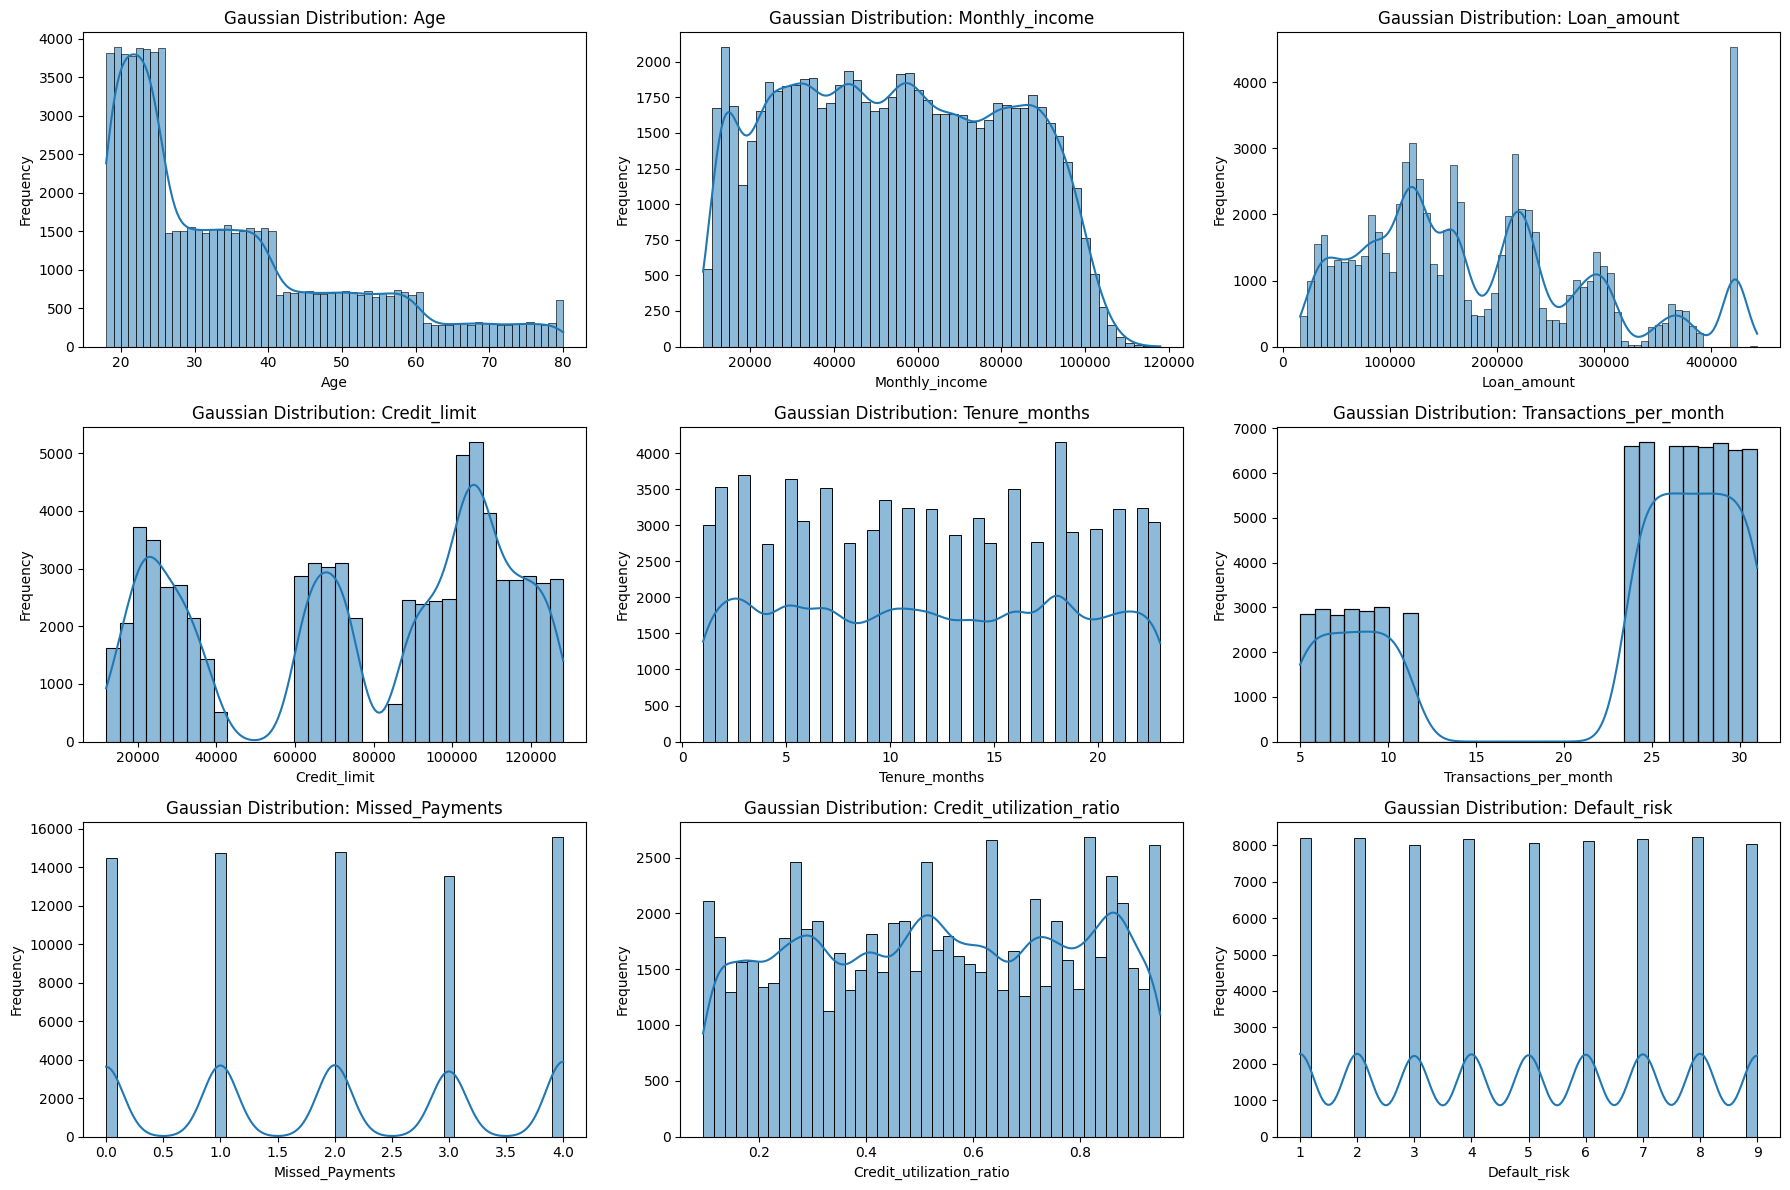

In [15]:
#1. Checking which numerical columns are normally distributed.

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):

    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(f'Gaussian Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

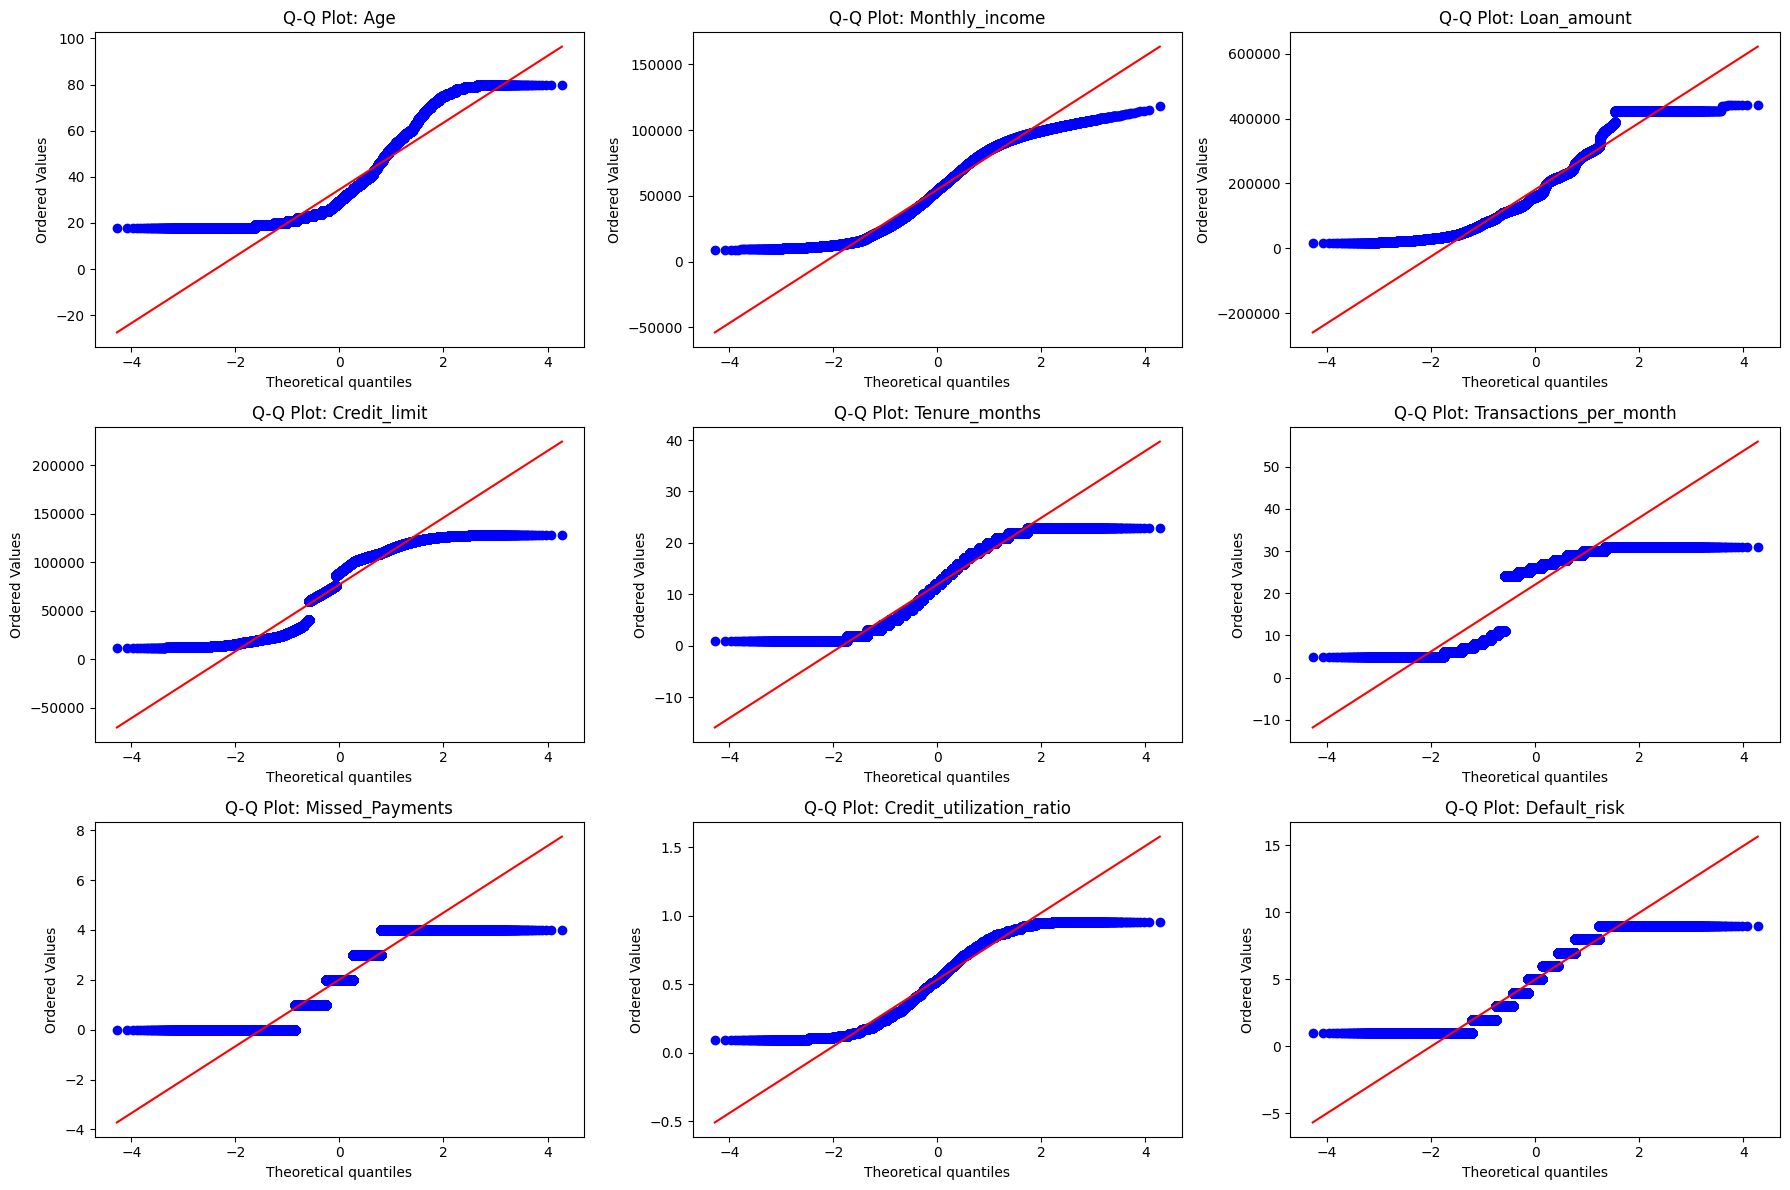

In [16]:
#2. Checking Normality in Numerical Columns with help of Q-Q Plot.

import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    stats.probplot(df[col],dist="norm",plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()

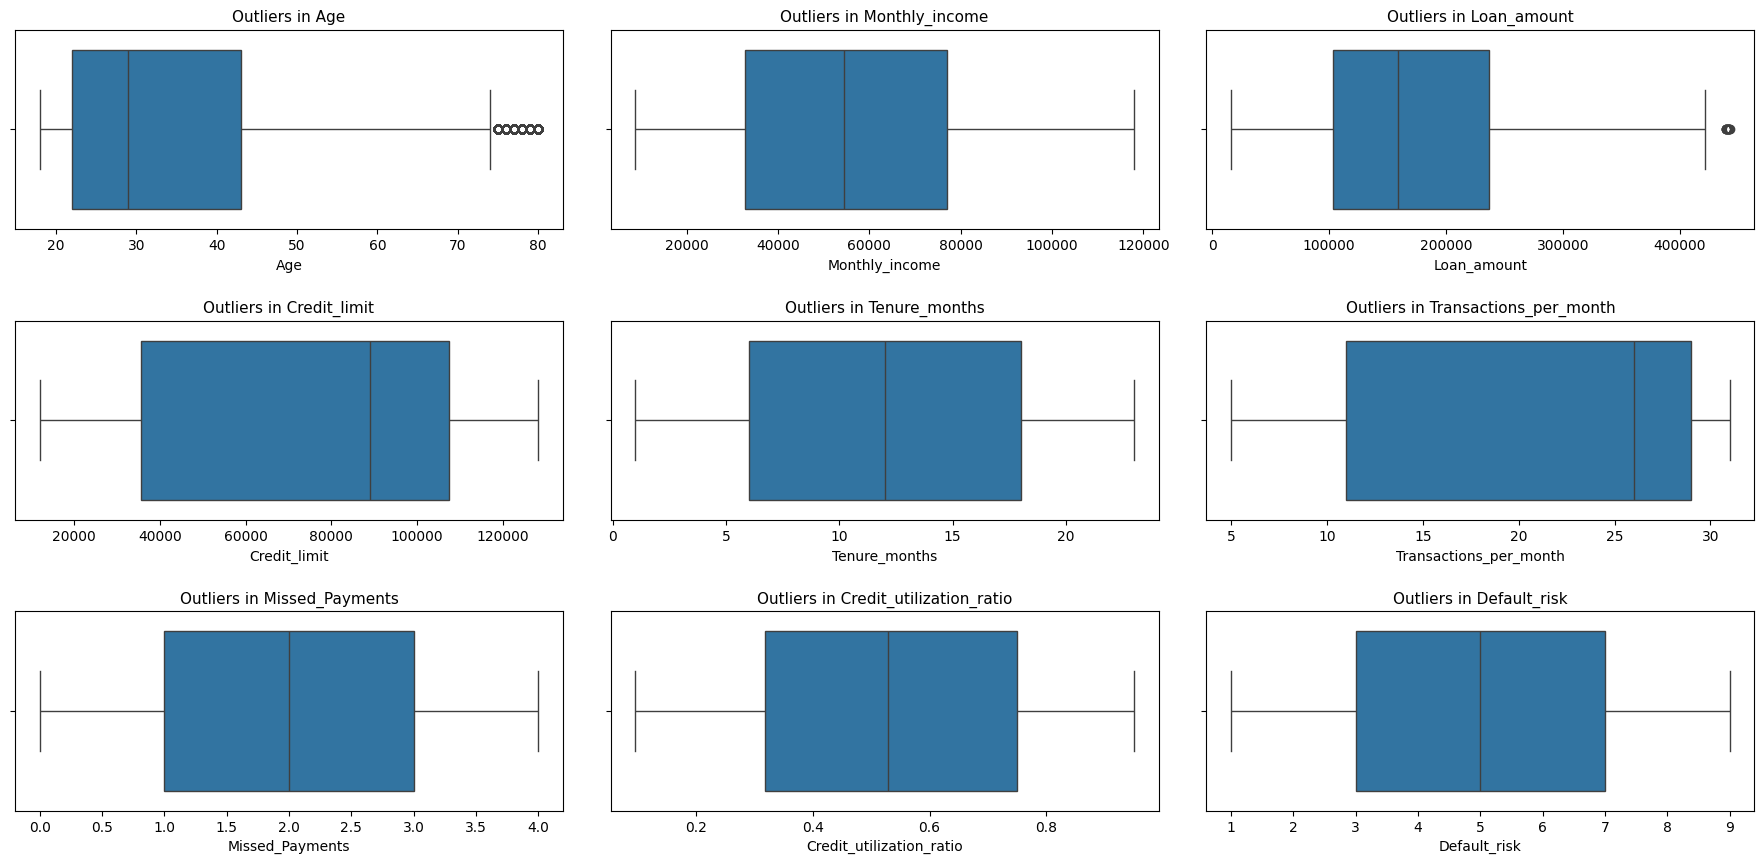

In [17]:
#3. Cheaking Outliers in Numerical Columns.

fig, axes = plt.subplots(3, 3, figsize=(18,9))
axes = axes.flatten()

for i,col in  enumerate(numerical_columns):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(f'Outliers in {col}',fontsize=11)
    axes[i].set_xlabel(col)

plt.tight_layout(pad=2.0)
plt.show()

Phase III. T-Test / Z-Test

1. T-Test & Z-Test on Loan Amount vs Age Category with respect to Gen Z.

In [18]:
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import ztest

# Gen Z vs Millennial
genz = df[df['Age_Category'] == 'Gen Z']['Loan_amount']
millennial = df[df['Age_Category'] == 'Millennial']['Loan_amount']

t_stat, p_value = ttest_ind(genz, millennial)
z_stat, p_value = ztest(genz, millennial)

print("Loan Amount: Gen Z vs Millennial")
print("T-statistic:", t_stat)
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

# Gen Z vs Boomer
genz = df[df['Age_Category'] == 'Gen Z']['Loan_amount']
boomer = df[df['Age_Category'] == 'Boomer']['Loan_amount']

t_stat, p_value = ttest_ind(genz, boomer)
z_stat, p_value = ztest(genz, boomer)

print("\nLoan Amount: Gen Z vs Boomer")
print("T-statistic:", t_stat)
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

# Gen Z vs Old Age
genz = df[df['Age_Category'] == 'Gen Z']['Loan_amount']

old_age = df[df['Age_Category'] == 'Old Age']['Loan_amount']

t_stat, p_value = ttest_ind(genz, old_age)
z_stat, p_value = ztest(genz, old_age)

print("\nLoan Amount: Gen Z vs Old Age")
print("T-statistic:", t_stat)
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

Loan Amount: Gen Z vs Millennial
T-statistic: 68.93564620472333
Z-statistic: 68.93564620472333
P-value: 0.0
Significant

Loan Amount: Gen Z vs Boomer
T-statistic: 106.78719500681302
Z-statistic: 106.78719500681302
P-value: 0.0
Significant

Loan Amount: Gen Z vs Old Age
T-statistic: 90.32451459974398
Z-statistic: 90.32451459974398
P-value: 0.0
Significant


Since, T-statistic & Z-statistic are coming out same there is no point using T-Test.

2. Z-Test on Monthly Income vs Age Category with respect to Gen Z.

In [19]:
from statsmodels.stats.weightstats import ztest

# Gen Z vs Millennial
genz = df[df['Age_Category'] == 'Gen Z']['Monthly_income']
millennial = df[df['Age_Category'] == 'Millennial']['Monthly_income']

z_stat, p_value = ztest(genz, millennial)
print("Monthly Income: Gen Z vs Millennial")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

# Gen Z vs Boomer
genz = df[df['Age_Category'] == 'Gen Z']['Monthly_income']
boomer = df[df['Age_Category'] == 'Boomer']['Monthly_income']

z_stat, p_value = ztest(genz, boomer)
print("\nMonthly Income: Gen Z vs Boomer")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

# Gen Z vs Old Age
genz = df[df['Age_Category'] == 'Gen Z']['Monthly_income']
old_age = df[df['Age_Category'] == 'Old Age']['Monthly_income']

z_stat, p_value = ztest(genz, old_age)
print("\nMonthly Income: Gen Z vs Old Age")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

Monthly Income: Gen Z vs Millennial
Z-statistic: -1.9911673027993582
P-value: 0.046462497250211635
Significant

Monthly Income: Gen Z vs Boomer
Z-statistic: -1.1759284460089905
P-value: 0.23962347057537603
Not Significant

Monthly Income: Gen Z vs Old Age
Z-statistic: -1.0086931472331468
P-value: 0.31312181928765226
Not Significant


3. Z-Test on Default Risk vs Age Category with respect to Gen Z.

In [20]:
from statsmodels.stats.weightstats import ztest

# Gen Z vs Millennial
genz = df[df['Age_Category'] == 'Gen Z']['Default_risk']
millennial = df[df['Age_Category'] == 'Millennial']['Default_risk']

z_stat, p_value = ztest(genz, millennial)
print("\nDefault Risk: Gen Z vs Millennial")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

# Gen Z vs Boomer
genz = df[df['Age_Category'] == 'Gen Z']['Default_risk']
boomer = df[df['Age_Category'] == 'Boomer']['Default_risk']

z_stat, p_value = ztest(genz, boomer)
print("\nDefault Risk: Gen Z vs Boomer")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

# Gen Z vs Old Age
genz = df[df['Age_Category'] == 'Gen Z']['Default_risk']
old_age = df[df['Age_Category'] == 'Old Age']['Default_risk']

z_stat, p_value = ztest(genz, old_age)
print("\nDefault Risk: Gen Z vs Old Age")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")


Default Risk: Gen Z vs Millennial
Z-statistic: -1.5546301025562503
P-value: 0.12003419020833461
Not Significant

Default Risk: Gen Z vs Boomer
Z-statistic: -1.0326333167575747
P-value: 0.3017755305291361
Not Significant

Default Risk: Gen Z vs Old Age
Z-statistic: -0.17586624258112263
P-value: 0.8603990264716179
Not Significant


4. Z-Test on Loan Amount vs Lending Company with respect to Slice.

In [21]:
from statsmodels.stats.weightstats import ztest

# Slice vs LazyPay
slice_company = df[df['Lending_company'] == 'Slice']['Loan_amount']

lazypay = df[df['Lending_company'] == 'LazyPay']['Loan_amount']

z_stat, p_value = ztest(slice_company, lazypay)

print("Loan Amount: Slice vs LazyPay")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")


# Slice vs Simpl
slice_company = df[df['Lending_company'] == 'Slice']['Loan_amount']

simpl = df[df['Lending_company'] == 'Simpl']['Loan_amount']

z_stat, p_value = ztest(slice_company, simpl)

print("\nLoan Amount: Slice vs Simpl")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")


# Slice vs ZestMoney
slice_company = df[df['Lending_company'] == 'Slice']['Loan_amount']

zestmoney = df[df['Lending_company'] == 'ZestMoney']['Loan_amount']

z_stat, p_value = ztest(slice_company, zestmoney)

print("\nLoan Amount: Slice vs ZestMoney")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

Loan Amount: Slice vs LazyPay
Z-statistic: 0.17348412182383702
P-value: 0.8622709075956043
Not Significant

Loan Amount: Slice vs Simpl
Z-statistic: -1.1451892689848473
P-value: 0.25213076262345324
Not Significant

Loan Amount: Slice vs ZestMoney
Z-statistic: 76.262425277274
P-value: 0.0
Significant


5. Z-Test on Default Risk vs Lending Company with respect to Slice.

In [22]:
from statsmodels.stats.weightstats import ztest

# Slice vs LazyPay
slice_company = df[df['Lending_company'] == 'Slice']['Default_risk']

lazypay = df[df['Lending_company'] == 'LazyPay']['Default_risk']

z_stat, p_value = ztest(slice_company, lazypay)

print("Default Risk: Slice vs LazyPay")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")


# Slice vs Simpl
slice_company = df[df['Lending_company'] == 'Slice']['Default_risk']

simpl = df[df['Lending_company'] == 'Simpl']['Default_risk']

z_stat, p_value = ztest(slice_company, simpl)

print("\nDefault Risk: Slice vs Simpl")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")


# Slice vs ZestMoney
slice_company = df[df['Lending_company'] == 'Slice']['Default_risk']

zestmoney = df[df['Lending_company'] == 'ZestMoney']['Default_risk']

z_stat, p_value = ztest(slice_company, zestmoney)

print("\nDefault Risk: Slice vs ZestMoney")
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Significant" if p_value < 0.05 else "Not Significant")

Default Risk: Slice vs LazyPay
Z-statistic: -1.399969899735342
P-value: 0.16152233233014757
Not Significant

Default Risk: Slice vs Simpl
Z-statistic: -0.03435029168409852
P-value: 0.9725978215447943
Not Significant

Default Risk: Slice vs ZestMoney
Z-statistic: -0.6984488629538179
P-value: 0.4848965274392808
Not Significant


Phase IV. Correlation Analysis

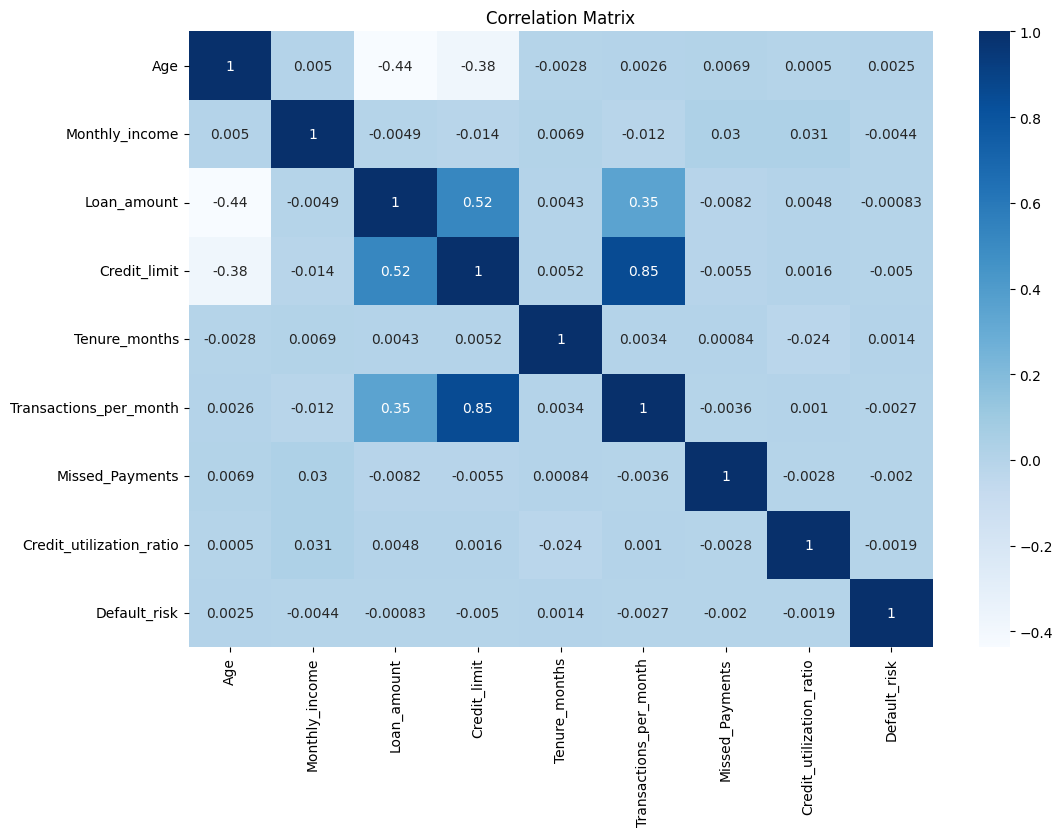

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Understanding relationships between numerical variables by Correlation Matrix.
correlation = df[numerical_columns].corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation,annot=True,cmap='Blues')
plt.title('Correlation Matrix')
plt.show()